# Minutes axis — establishing the unit of analysis *(population)*

*Read-only informative artifact. Sits in the **Descriptive** tier of the
analytics maturity model (POPULATION_DESIGN.md §1): it describes what the
minutes axis looks like, nothing more. It produces no gate decisions and no
PROCEED/STOP verdict.*

## What this notebook establishes (axis setup)

This is the **axis-setup** notebook for the `population/` layer. The layer's job
is *relational* — how the target Y and each signal X sit **across** the minutes
axis — and that work needs a well-defined axis to read against. This notebook
supplies it, describing only the *shape* of `minutes` itself (univariate). Two
things:

- **Is the minutes distribution bimodal?** A full-match wall plus a separate
  cameo/partial hump — the two-regime shape a single mean or median hides, and
  the reason this layer **bins** minutes rather than averaging them.
- **Where does the secure-minutes mass sit, by position?** The 60+ share that
  justifies where the `60`-minute **band edge** falls — the edge the relational
  notebooks then read against.

Everything below is **season-pooled** over the study range, on the
**participation** population (`minutes > 0` — the player actually featured). It
does **not** impose 60 as a gate and says nothing about scoring. How Y sits
across these bands is `points_by_minutes_band.ipynb` (bands × Y); how each
signal X sits across them is `signals_by_minutes_band.ipynb` (bands × X);
whether the population scope choice moves the signal–points association is
`scope_sensitivity.ipynb`.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and to the **participation** population (`minutes > 0`), and build position
cohorts.

The population is everyone who **actually featured**: available players with
`minutes > 0`. This is a **participation** filter (the player appeared), **not
a performance gate**. `minutes` can be NULL for some rows (blank-gameweek
rows); `minutes > 0` naturally excludes those (NULL comparisons are False).

This notebook deliberately **does not** impose the 60-minute boundary — it is
the layer that *describes* minutes so that boundary can be characterised
elsewhere. Baking it in here would pre-judge the very landscape we are meant to
map.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

POSITIONS = ["GK", "DEF", "MID", "FWD"]
mart = _result.mart

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

# Analytical population: PARTICIPATION filter, not a performance gate.
# minutes > 0 naturally excludes NULL (blank-gameweek) rows.
# DGW excluded for now (is_dgw == False) -- drops the fixture-doubling confound
# (the ~180-minute rows), so the minutes axis is single-fixture and clean.
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()

cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded (participation, not a performance gate), n = 11,190 player-gameweeks
  GK:    747
  DEF:  3,845
  MID:  5,208
  FWD:  1,390


## (a) Minutes distribution by position — is it bimodal?

**What we measure** — the univariate shape of `minutes` within each position
cohort (count, mean, median, std, percentiles, skew) via `compare_cohorts`,
plus a by-position histogram. The **histogram is the primary artifact**; the
table supports it.

*Stat glossary (this table is **minutes**, not points):* **mean** — average
minutes, but on a bimodal axis it lands in the empty valley between the two
modes and describes no actual appearance; **median** — the typical minutes a
featured player logs; **std** — spread around the mean, large precisely because
cameos and full games mix; **IQR (p75−p25)** — spread of the middle 50%, robust
to the bimodal shape; **p90/p99** — the high end; with DGW excluded the ceiling
is a single full match (p99 ≈ 90), not the old ~180 double-gameweek rows;
**skew** — negative = a left tail of short/cameo outings pulling down from a
full-90 mode.

**What it means** — this is the shape that *defines the axis*. The distribution
is **bimodal** for outfield positions — a full-90 wall plus a separate cameo/sub
hump — which is exactly why this layer bins minutes instead of averaging them: a
single mean sits in the valley between the two modes and describes no real
appearance. The cameo/partial mass grows up the pitch (the median falls
GK → FWD).

**What it doesn't mean** — these are **season-pooled** minutes across all
players and weeks, not any one player's week-to-week reliability (a
within-player question, deferred to `temporal/`). And minutes say nothing about
scoring — a full 90 can blank, a cameo can return. This section describes the
*shape of the exposure axis*; how scoring sits across it is
`points_by_minutes_band.ipynb`.

**Guiding question (directive)** — *Determine how minutes distribute by position
— establish that the distribution is bimodal (full-match mass vs cameo/partial
mass).*

In [2]:
mins_by_pos = compare_cohorts(cohorts, value_col="minutes")
display(
    mins_by_pos[
        ["count", "mean", "median", "std", "p25", "p75", "p90", "p99", "min", "max", "skew"]
    ].round(2)
)

,count,mean,median,std,p25,p75,p90,p99,min,max,skew
cohort,,,,,,,,,,,
GK,747,89.150,90.000,7.020,90.000,90.000,90.000,90.000,4,90,-9.210
DEF,3845,72.110,90.000,29.710,64.000,90.000,90.000,90.000,1,90,-1.400
MID,5208,59.790,73.000,32.000,27.000,90.000,90.000,90.000,1,90,-0.580
FWD,1390,52.920,63.500,32.650,19.000,87.000,90.000,90.000,1,90,-0.250


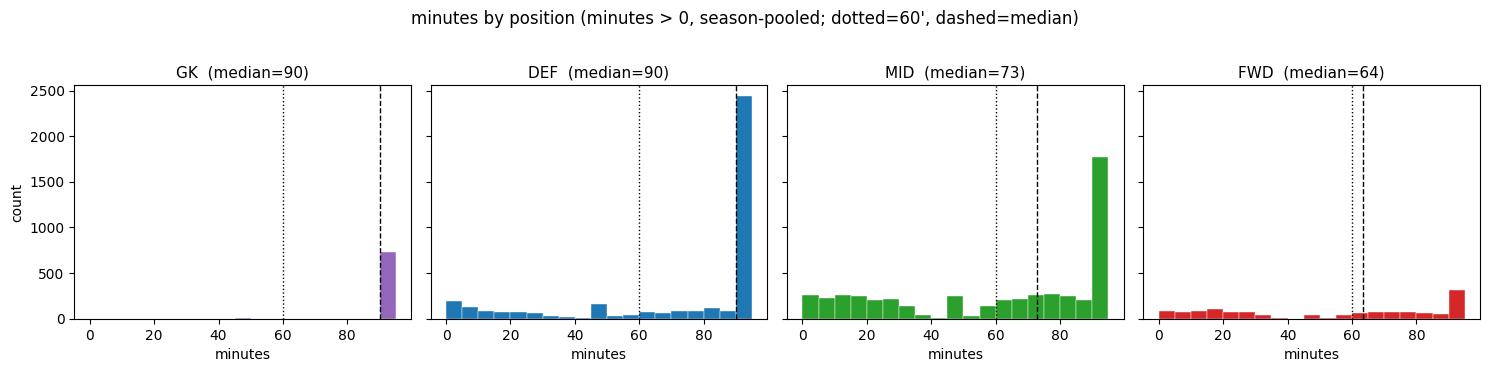

In [3]:
# The minutes distribution is bimodal -- a full-90 wall plus a cameo/sub hump --
# which a mean or median hides. Overlaid per-position histograms show the shape.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
bins = range(0, 100, 5)
for ax, pos in zip(axes, POSITIONS):
    s = cohorts[pos]["minutes"].dropna().astype(float)
    ax.hist(s, bins=bins, color=colours[pos], edgecolor="white", linewidth=0.3)
    ax.axvline(60, color="black", linestyle=":", linewidth=1.0)
    ax.axvline(s.median(), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{pos}  (median={s.median():.0f})", fontsize=11)
    ax.set_xlabel("minutes")
axes[0].set_ylabel("count")
fig.suptitle("minutes by position (minutes > 0, season-pooled; dotted=60', dashed=median)", y=1.02)
plt.tight_layout()
plt.show()

## (b) Minutes-band composition by position — where the 60+ mass sits

**What we measure** — for each position, the share of featured player-gameweeks
falling into three **minutes bands**: `1-29` (cameo), `30-59` (partial), and
`60+` (secure). Bands collapse at `60+` because FPL's scoring rules do not
distinguish `60-89` from `90` — both are the same appearance / clean-sheet
regime — so `60+` is the rule-aligned band rather than an invented `90` cut.
Computed inline as proportions within each cohort.

**What it means** — this is what **justifies the `60`-minute band edge** the
relational notebooks read against. The `60+` share is the secure-minutes mass;
the `1-29` + `30-59` share is the cameo/partial mass. For every outfield
position both regions are populated, so `60` falls between two real humps rather
than cutting through empty space — a descriptive band edge grounded in the
shape, not an imposed threshold.

**What it doesn't mean** — these are **season-pooled** band shares (DGW
excluded), not a forecast of next week's minutes for any player. The band edges
(30 / 60) are descriptive conveniences; the `60` edge is the one
`points_by_minutes_band.ipynb` reads scoring against, **not** a gate imposed
here. Band membership says nothing about points returned within the band.

**Guiding question (directive)** — *Quantify each position's secure-minutes
(60+) share, justifying where the 60-minute band edge sits.*

In [4]:
# Minutes-band composition within each position cohort. Edges 30 / 60 are
# descriptive; the 60 edge (FPL's scoring step) is the one
# points_by_minutes_band.ipynb reads scoring against, NOT imposed here as a gate.
# Bands collapse at 60+ because FPL does not distinguish 60-89 from 90 (same
# appearance / clean-sheet regime). DGW already excluded in setup, so 60+ is a
# single full match. The 60+ share IS the secure-minutes share.
BANDS = ["1-29", "30-59", "60+"]

def _band(mn):
    if mn < 30:
        return "1-29"
    if mn < 60:
        return "30-59"
    return "60+"

rows = []
for pos in POSITIONS:
    c = cohorts[pos]
    bands = c["minutes"].dropna().astype(int).map(_band)
    share = bands.value_counts(normalize=True).reindex(BANDS).fillna(0.0) * 100
    row = {"position": pos, "n": len(bands)}
    for b in BANDS:
        row[f"{b}_%"] = round(float(share[b]), 1)
    rows.append(row)
band_composition = pd.DataFrame(rows)
display(band_composition)

,position,n,1-29_%,30-59_%,60+_%
0,GK,747,0.500,0.800,98.700
1,DEF,3845,16.100,7.400,76.600
2,MID,5208,27.400,11.500,61.100
3,FWD,1390,36.300,10.400,53.400


## What the minutes axis looks like

Plain-language summary of the axis shape (not a verdict, not relational):

- The minutes distribution is **bimodal** for outfield positions — a full-90
  wall plus a separate cameo/sub hump — which is why this layer bins minutes and
  why the histogram, not the mean, carries the shape. Median minutes fall up the
  pitch: **GK 90, DEF 90, MID 73, FWD 63**. GK is almost entirely full-90 mass
  (mean ≈ 89) — exposure in goal is effectively binary.
- **Secure-minutes (60+) share falls up the pitch** — GK **98.7%**, DEF
  **76.6%**, MID **61.1%**, FWD **53.4%**. This is where the mass sits relative
  to the `60`-minute mark, and it is what justifies `60` as a **band edge**: for
  every outfield position it falls between a populated full-match region and a
  populated cameo/partial region.
- **DGW is excluded** (`is_dgw == False`), so the axis is single-fixture: no
  ~180-minute doubled rows, and the high end of `minutes` is a clean single full
  match. Per-fixture DGW treatment is the `fixture/` layer's job.

All figures are **whole-season**, season-pooled, over the **participation**
population (`minutes > 0`, DGW excluded). This notebook establishes the **axis**
only — univariate shape and band edges. How the target Y sits across these bands
is `points_by_minutes_band.ipynb`; how each signal X sits across them is
`signals_by_minutes_band.ipynb`; whether the population scope choice moves the
signal–points association is `scope_sensitivity.ipynb`; within-player minutes
dynamics are deferred to the `temporal/` layer.